# Preliminary Setup

In [1]:
import getpass
import os

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Provide your {var}: ")

# _set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("OPENROUTER_API_KEY")
_set_if_undefined("OPENROUTER_BASE_URL")
_set_if_undefined("TAVILY_API_KEY")

Provide your OPENROUTER_API_KEY:  ········
Provide your OPENROUTER_BASE_URL:  ········
Provide your TAVILY_API_KEY:  ········


In [2]:
!pip install -U langgraph langchain_community langchain-tavily langchain_experimental langchain_openai

# All Imports

In [3]:
import os
from typing import Annotated, List, Optional, Dict, Literal, TypedDict

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch

from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command

C:\Users\vinay\AppData\Local\Temp\ipykernel_3748\1895543749.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


# Define the tools

In [4]:
@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )


@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections"],
    file_name: Annotated[str, "File path to save the outline"],
) -> Annotated[str, "Path of the saved outline file"]:
    """Create and save an outline."""
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    with open(file_to_use, "w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")

    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from"],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    with open(file_to_use, "r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written to the document"],
    file_name: Annotated[str, "File path to save the document"],
) -> str:
    """Create and save a text document."""
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    with open(file_to_use, "w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "File path to save the document"],
    inserts: Annotated[Dict[int, str], "Dictionary where key is the line number and value is the text to be inserted at the line"],
) -> str:
    """Edit a document by inserting text at specified line numbers"""
    file_to_use = os.path.join(os.getcwd(), "temp", file_name)
    with open(file_to_use, "r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range"

    with open(file_name, "w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of any value,
    you should print it with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

# Define the supervisor

In [5]:
class State(MessagesState):
    next: str


def make_supervisor_node(llm: BaseChatModel, members: List[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        next: Literal[*options]

    def supervisor(state: State) -> Command[Literal[*members, "__end__"]]:
        messages = [
            {"role": "system", "content": system_prompt}
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor

# Define the Agent Teams

### 1. Research Team

In [6]:
# llm = ChatOpenAI(model="gpt-4o")
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

tavily_tool = TavilySearch(max_results=3)

search_agent = create_react_agent(llm, tools=[tavily_tool])

def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update = {
            "messages": [HumanMessage(content=result["messages"][-1].content, name="search")]
        },
        goto = "supervisor"
    )

web_scrapper_agent = create_react_agent(llm, tools=[scrape_webpages])

def web_scrapper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scrapper_agent.invoke(state)
    return Command(
        update = {
            "messages": [HumanMessage(content=result["messages"][-1].content, name="web_scrapper")]
        },
        goto = "supervisor"
    )

research_supervisor_node = make_supervisor_node(llm, ["search", "web_scrapper"])

C:\Users\vinay\AppData\Local\Temp\ipykernel_3748\1299784149.py:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  search_agent = create_react_agent(llm, tools=[tavily_tool])
C:\Users\vinay\AppData\Local\Temp\ipykernel_3748\1299784149.py:21: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  web_scrapper_agent = create_react_agent(llm, tools=[scrape_webpages])


In [22]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scrapper", web_scrapper_node)

research_builder.add_edge(START, "supervisor")
research_graph = research_builder.compile()

### 2. Writing Team

In [23]:
doc_writer_agent = create_react_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    prompt=(
        "You can read, write and edit documents based on note taker's outlines. "
        "Don't ask follow up questions."
    ),
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={
            "messages": [HumanMessage(content=result["messages"][-1].content, name="doc_writer")]
        },
        goto="supervisor",
    )

note_taking_agent = create_react_agent(
    llm,
    tools=[create_outline, read_document],
    prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow up questions."
    ),
)

def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="note_taker")
            ]
        },
        goto="supervisor",
    )

chart_generating_agent = create_react_agent(
    llm,
    tools=[read_document, python_repl_tool],
)

def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="chart_generator")
            ]
        },
        goto="supervisor",
    )

doc_writing_supervisor_node = make_supervisor_node(
    llm, ["doc_writer", "note_taker", "chart_generator"]
)

C:\Users\vinay\AppData\Local\Temp\ipykernel_3748\1821503043.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  doc_writer_agent = create_react_agent(
C:\Users\vinay\AppData\Local\Temp\ipykernel_3748\1821503043.py:19: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  note_taking_agent = create_react_agent(
C:\Users\vinay\AppData\Local\Temp\ipykernel_3748\1821503043.py:39: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_generating_agent = create_react_agent(


In [24]:
writing_builder = StateGraph(State)
writing_builder.add_node("supervisor", doc_writing_supervisor_node)
writing_builder.add_node("doc_writer", doc_writing_node)
writing_builder.add_node("note_taker", note_taking_node)
writing_builder.add_node("chart_generator", chart_generating_node)

writing_builder.add_edge(START, "supervisor")

writing_graph = writing_builder.compile()

In [25]:
for s in writing_graph.stream(
    {
        "messages": [
            (
                "user",
                "Write an outline for a poem about dogs and after that write the poem itself and store it"
            )
        ]
    },
    {"recursion_limit": 30},
):
    print(s)
    print("---")

{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='The outline for the poem about dogs and the poem itself have been written and saved successfully:\n\n1. **Outline**: [dog_poem_outline.txt](sandbox:/dog_poem_outline.txt)\n2. **Poem**: [dog_poem.txt](sandbox:/dog_poem.txt)', additional_kwargs={}, response_metadata={}, name='doc_writer', id='4a3e310f-6998-4362-8cdc-d09acd79024a')]}}
---
{'supervisor': {'next': 'note_taker'}}
---
{'note_taker': {'messages': [HumanMessage(content='The outline and the poem about dogs have been successfully written and saved. You can access them using the following links:\n\n1. **Outline**: [dog_poem_outline.txt](sandbox:/dog_poem_outline.txt)\n2. **Poem**: [dog_poem.txt](sandbox:/dog_poem.txt)', additional_kwargs={}, response_metadata={}, name='note_taker', id='e8bf8d91-b6c0-4dd7-8a99-ff56716013d9')]}}
---
{'supervisor': {'next': '__end__'}}
---


# End-to-end Graph

### Implement the graph

In [26]:
teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor",
    )

def call_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor",
    )

super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_writing_team)

super_builder.add_edge(START, "supervisor")

super_graph = super_builder.compile()

### Visualize the graph

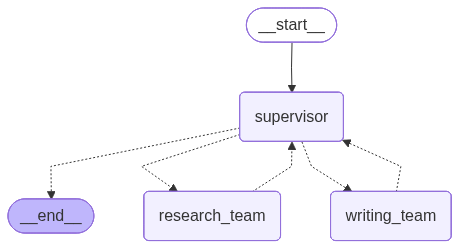

In [27]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))

### Run the graph

In [28]:
for s in super_graph.stream(
    {
        "messages": [
            (
                "user",
                "Research why the gold price has been increasing crazily in 2025. Come up with the reasons."
            )
        ]
    },
    {"recursion_limit": 1000},
):
    print(s)
    print("----")

{'supervisor': {'next': 'research_team'}}
----
{'research_team': {'messages': [HumanMessage(content="The significant increase in gold prices in 2025 can be attributed to several key factors:\n\n1. **Central Bank Demand**: There has been a notable increase in gold purchases by central banks, particularly in emerging markets like Russia, China, and India. The World Gold Council's 2025 Central Bank Gold Reserves Survey indicated that 95% of central bankers anticipate rising global gold reserves, reflecting a strategic move to hedge against currency fluctuations, especially against the U.S. dollar.\n\n2. **Macroeconomic Conditions**: The economic environment in 2025 has been influenced by a weakening employment situation in the U.S., which has prompted expectations of lower interest rates from the Federal Reserve. Lower interest rates make gold an attractive investment compared to cash holdings and fixed income assets, leading to increased buying interest.\n\n3. **Inflation Factors**: Ongo